In [47]:
from util.utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model
import torch
from ultralytics import YOLO
from PIL import Image
device = 'cuda'
model_path='weights/icon_detect/model.pt'

som_model = get_yolo_model(model_path)

som_model.to(device)
print('model to {}'.format(device))

model to cuda


In [48]:
# two choices for caption model: fine-tuned blip2 or florence2
import importlib
# import util.utils
# importlib.reload(utils)
from util.utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model
caption_model_processor = get_caption_model_processor(model_name="florence2", model_name_or_path="weights/icon_caption_florence", device=device)



/home/carbaje/anaconda3/envs/hcktn_blr/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [49]:
som_model.device, type(som_model) 

(device(type='cuda', index=0), ultralytics.models.yolo.model.YOLO)

In [50]:
# reload utils
import importlib
import util
importlib.reload(util)
# from utils import get_som_labeled_img, check_ocr_box, get_caption_model_processor, get_yolo_model

#image_path = 'imgs/google_page.png'
#image_path = 'imgs/windows_home.png'
# image_path = 'imgs/windows_multitab.png'
# image_path = 'imgs/omni3.jpg'
#image_path = 'imgs/ios.png'
#image_path = 'imgs/word.png'
image_path = '/home/carbaje/Documents/Learning/hackaton_blr/ss_test/inputs/20260406-0003.jpeg'
# image_path = 'imgs/excel2.png'

image = Image.open(image_path)
image_rgb = image.convert('RGB')
print('image size:', image.size)

box_overlay_ratio = max(image.size) / 3200
draw_bbox_config = {
    'text_scale': 0.8 * box_overlay_ratio,
    'text_thickness': max(int(2 * box_overlay_ratio), 1),
    'text_padding': max(int(3 * box_overlay_ratio), 1),
    'thickness': max(int(3 * box_overlay_ratio), 1),
}
BOX_TRESHOLD = 0.05

import time
start = time.time()
ocr_bbox_rslt, is_goal_filtered = check_ocr_box(image_path, display_img = False, output_bb_format='xyxy', goal_filtering=None, easyocr_args={'paragraph': False, 'text_threshold':0.9}, use_paddleocr=True)
text, ocr_bbox = ocr_bbox_rslt
cur_time_ocr = time.time() 

dino_labled_img, label_coordinates, parsed_content_list = get_som_labeled_img(image_path, som_model, BOX_TRESHOLD = BOX_TRESHOLD, output_coord_in_ratio=True, ocr_bbox=ocr_bbox,draw_bbox_config=draw_bbox_config, caption_model_processor=caption_model_processor, ocr_text=text,use_local_semantics=True, iou_threshold=0.7, scale_img=False, batch_size=128)
cur_time_caption = time.time() 


image size: (1119, 388)

0: 448x1280 12 icons, 17.9ms
Speed: 2.8ms preprocess, 17.9ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 1280)
no ocr bbox!!!
len(filtered_boxes): 11 0
time to get parsed content: 0.10817289352416992


/home/carbaje/anaconda3/envs/hcktn_blr/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:615: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


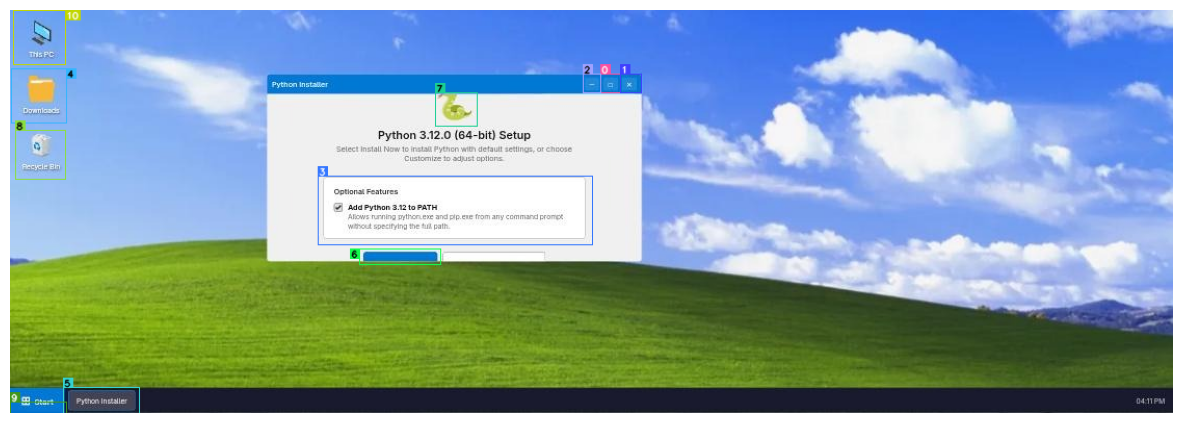

In [51]:
# plot dino_labled_img it is in base64
import base64
import matplotlib.pyplot as plt
import io
plt.figure(figsize=(15,15))

image = Image.open(io.BytesIO(base64.b64decode(dino_labled_img)))
plt.axis('off')

plt.imshow(image)
# print(len(parsed_content_list))


In [52]:
import pandas as pd
df = pd.DataFrame(parsed_content_list)
df['ID'] = range(len(df))

df

,type,bbox,interactivity,content,ID
0,icon,"[0.5084202885627747, 0.16157226264476776, 0.52...",True,Maximize window.,0
1,icon,"[0.52527916431427, 0.16164720058441162, 0.5428...",True,Close (Ctrl+Shift+F),1
2,icon,"[0.4925422966480255, 0.16134166717529297, 0.50...",True,a loading or buffering indicator.,2
3,icon,"[0.2648966312408447, 0.41339123249053955, 0.50...",True,A calendar application.,3
4,icon,"[0.0009017884731292725, 0.14847548305988312, 0...",True,Drammaad:,4
5,icon,"[0.046226538717746735, 0.935932457447052, 0.11...",True,Pyramid Indicator,5
6,icon,"[0.30080071091651917, 0.5940213203430176, 0.37...",True,a credit card.,6
7,icon,"[0.3657590448856354, 0.2067456841468811, 0.401...",True,Selection,7
8,icon,"[0.00449432572349906, 0.29957178235054016, 0.0...",True,Recycle Bin,8
9,icon,"[0.0, 0.9717790484428406, 0.048396915197372437...",True,System,9


In [53]:
parsed_content_list

[{'type': 'icon',
  'bbox': [0.5084202885627747,
   0.16157226264476776,
   0.5246389508247375,
   0.20643894374370575],
  'interactivity': True,
  'content': 'Maximize window.'},
 {'type': 'icon',
  'bbox': [0.52527916431427,
   0.16164720058441162,
   0.5428057909011841,
   0.20686985552310944],
  'interactivity': True,
  'content': 'Close (Ctrl+Shift+F)'},
 {'type': 'icon',
  'bbox': [0.4925422966480255,
   0.16134166717529297,
   0.508110761642456,
   0.2072228640317917],
  'interactivity': True,
  'content': 'a loading or buffering indicator.'},
 {'type': 'icon',
  'bbox': [0.2648966312408447,
   0.41339123249053955,
   0.5005241632461548,
   0.583188533782959],
  'interactivity': True,
  'content': 'A calendar application.'},
 {'type': 'icon',
  'bbox': [0.0009017884731292725,
   0.14847548305988312,
   0.04868360981345177,
   0.2824508249759674],
  'interactivity': True,
  'content': 'Drammaad:'},
 {'type': 'icon',
  'bbox': [0.046226538717746735, 0.935932457447052, 0.1113271638